<a href="https://colab.research.google.com/github/Mayuri172-atole/Sugarcane-Leaf-Disease-Classification-Using-Deep-Learning/blob/main/Copy_of_sugarcane_disease_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install dependencies
!pip install kaggle tensorflow opencv-python


In [ ]:
!mv kaggle\(3\).json kaggle.json
# 2. Upload Kaggle API key
from google.colab import files
files.upload()  # upload kaggle.json


Saving kaggle(3).json to kaggle(3).json


{'kaggle(3).json': b'{"username":"sarthaksanjayatole","key":"78070ab815f4d6357b1327c3da849f39"}'}

In [ ]:

# 3. Setup Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
# 4. Download dataset from Kaggle
!kaggle datasets download -d nirmalsankalana/sugarcane-leaf-disease-dataset
!unzip sugarcane-leaf-disease-dataset.zip -d sugarcane_data


Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/sugarcane-leaf-disease-dataset
License(s): CC0-1.0
 93% 148M/160M [00:00<00:00, 373MB/s]
100% 160M/160M [00:00<00:00, 414MB/s]
Archive:  sugarcane-leaf-disease-dataset.zip
  inflating: sugarcane_data/Healthy/healthy (1).jpeg  
  inflating: sugarcane_data/Healthy/healthy (10).jpeg  
  inflating: sugarcane_data/Healthy/healthy (100).jpeg  
  inflating: sugarcane_data/Healthy/healthy (101).jpeg  
  inflating: sugarcane_data/Healthy/healthy (102).jpeg  
  inflating: sugarcane_data/Healthy/healthy (103).jpeg  
  inflating: sugarcane_data/Healthy/healthy (104).jpeg  
  inflating: sugarcane_data/Healthy/healthy (105).jpeg  
  inflating: sugarcane_data/Healthy/healthy (106).jpeg  
  inflating: sugarcane_data/Healthy/healthy (107).jpeg  
  inflating: sugarcane_data/Healthy/healthy (108).jpeg  
  inflating: sugarcane_data/Healthy/healthy (109).jpeg  
  inflating: sugarcane_data/Healthy/healthy (11).jpeg  
  inflating: sugarcane_data/He

In [ ]:
# Import TensorFlow & other libs
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2


In [ ]:
# 6. Dataset setup
dataset_path = "/content/sugarcane_data"
img_height, img_width = 224, 224
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Optimize pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 2521 files belonging to 5 classes.
Using 2017 files for training.
Found 2521 files belonging to 5 classes.
Using 504 files for validation.
Classes: ['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']


In [ ]:
# 7. Build Transfer Learning model (ResNet152V2)
base_model = tf.keras.applications.ResNet152V2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze weights

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [ ]:
# 8. Train model
epochs = 15
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

# Save model
model.save("sugarcane_disease_model.h5")
print("✅ Saved model as sugarcane_disease_model.h5")


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 691ms/step - accuracy: 0.5535 - loss: 1.1809 - val_accuracy: 0.7837 - val_loss: 0.5971
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - accuracy: 0.8225 - loss: 0.4954 - val_accuracy: 0.8194 - val_loss: 0.5001
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step - accuracy: 0.8973 - loss: 0.3176 - val_accuracy: 0.8433 - val_loss: 0.4612
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - accuracy: 0.9277 - loss: 0.2263 - val_accuracy: 0.8234 - val_loss: 0.4921
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 222ms/step - accuracy: 0.9384 - loss: 0.1856 - val_accuracy: 0.8452 - val_loss: 0.4595
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 221ms/step - accuracy: 0.9669 - loss: 0.1169 - val_accuracy: 0.8631 - val_loss: 0.4226
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - accuracy: 0.9688 - loss: 0.1053 - val_accuracy: 0.8651 - val_loss: 0.4312
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - accuracy: 0.9760 - loss: 0.0781 - val_accu

✅ Saved model as sugarcane_disease_model.h5


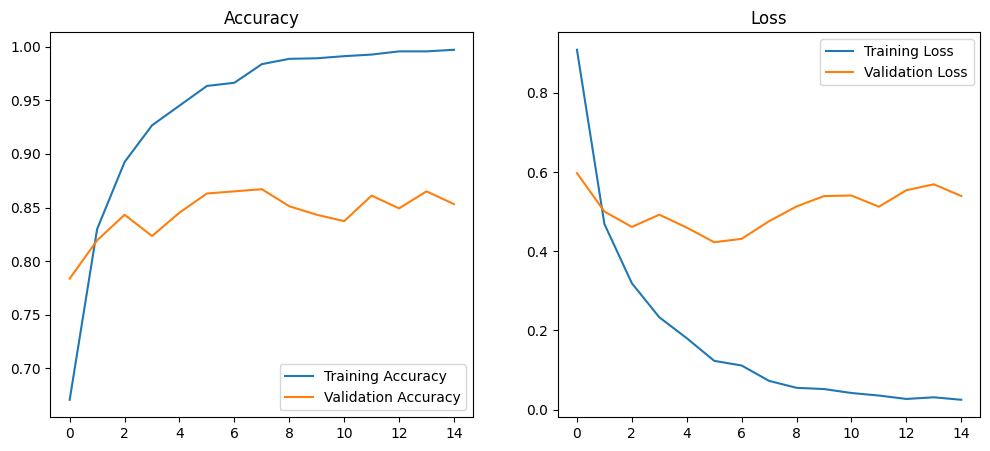

In [ ]:
# 9. Training curves (Accuracy & Loss)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(); plt.title("Accuracy")
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(); plt.title("Loss")
plt.show()


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step


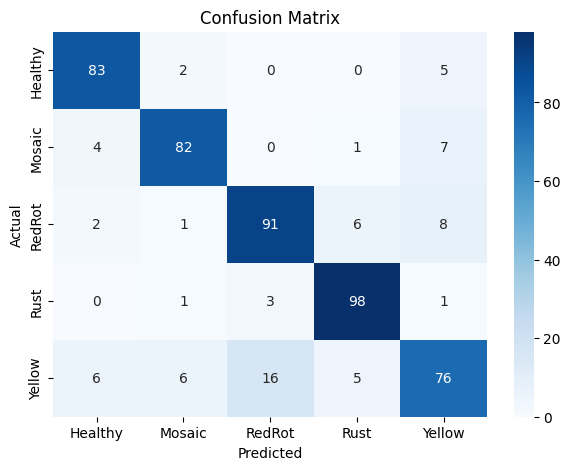

📑 Classification Report:


,precision,recall,f1-score,support
Healthy,0.873684,0.922222,0.897297,90.000000
Mosaic,0.891304,0.872340,0.881720,94.000000
RedRot,0.827273,0.842593,0.834862,108.000000
Rust,0.890909,0.951456,0.920188,103.000000
Yellow,0.783505,0.697248,0.737864,109.000000
accuracy,0.853175,0.853175,0.853175,0.853175
macro avg,0.853335,0.857172,0.854386,504.000000
weighted avg,0.851042,0.853175,0.851211,504.000000


In [ ]:
# 10. Confusion Matrix & Classification Report
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

# Get predictions on validation set
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print("📑 Classification Report:")
display(df_report)


In [ ]:
# 11. Prediction function (show image + label)
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_height, img_width))
    img_norm = np.expand_dims(img_resized/255.0, axis=0)

    pred = model.predict(img_norm)
    pred_class = class_names[np.argmax(pred)]

    print(f"Image: {os.path.basename(img_path)}")
    print(f"Predicted Disease: {pred_class}")
    plt.imshow(img)
    plt.title(f"Predicted: {pred_class}")
    plt.axis("off")
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

def predict_image(img_path):
    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))  # for model input
    img_norm = img_resized / 255.0

    # Get prediction from the model
    pred = model.predict(np.expand_dims(img_norm, axis=0))

    # Get class labels
    pred_class = class_names[np.argmax(pred)]

    # Print and display image with prediction
    print(f"Image: {os.path.basename(img_path)}")
    print(f"Predicted Disease: {pred_class}")

    plt.imshow(img)
    plt.title(f"Predicted: {pred_class}")
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Image: healthy (1).jpeg
Predicted Disease: Mosaic


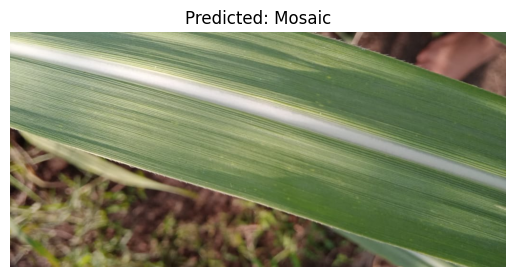

In [ ]:
# Example
predict_image("sugarcane_data/Healthy/healthy (1).jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Image: healthy (10).jpeg
Predicted Disease: disease_2


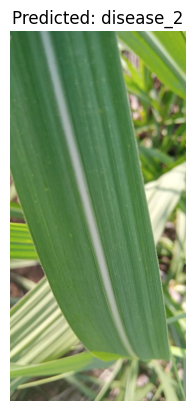

In [ ]:
predict_image("/content/sugarcane_data/Healthy/healthy (10).jpeg")

In [ ]:
# Save as HDF5 format
model.save("sugarcane_disease_model.h5")

# OR save as new Keras format
model.save("sugarcane_disease_model.keras")

print("✅ Model saved successfully")


✅ Model saved successfully


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Image: healthy (1).jpeg
Predicted Disease: Mosaic


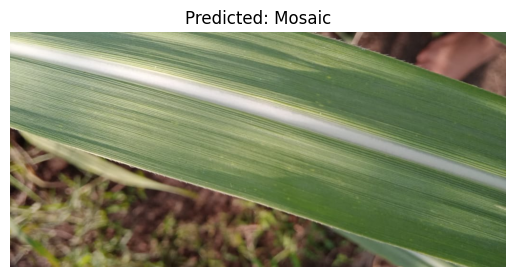

In [ ]:
from tensorflow.keras.models import load_model

# Load model
loaded_model = load_model("sugarcane_disease_model.h5")

# Use loaded model for prediction
predict_image("sugarcane_data/Healthy/healthy (1).jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Image: healthy (1).jpeg
Predicted Disease: Mosaic


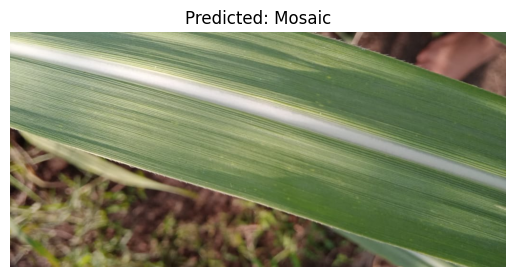

In [ ]:
from tensorflow.keras.models import load_model

# Load model
loaded_model = load_model("sugarcane_disease_model.keras")

# Use for prediction
predict_image("sugarcane_data/Healthy/healthy (1).jpeg")

In [ ]:
# Save as HDF5 format
model.save("sugarcane_disease_model.h5")

# OR save as new Keras format
model.save("sugarcane_disease_model.keras")

print("✅ Model saved successfully")


✅ Model saved successfully


In [ ]:
from tensorflow.keras.models import load_model

# Load your trained Keras model (.h5 file)
#model = load_model('sugarcane_disease_model.h5')
model = load_model('sugarcane_disease_model.keras')
model.save('my_cnn_model.keras')
print("Model saved as my_cnn_model.keras")  # Load the correct model file

# Example: predict on the last image in validation set
# This part assumes you have run the cells that define val_ds and predict_image
# If you want to predict on a custom image, you can directly call predict_image('path/to/your/image.jpg')
# For example:
# predict_image("/content/sugarcane_data/Healthy/healthy (1).jpeg")

Model saved as my_cnn_model.keras


In [ ]:
from google.colab import files
files.download("sugarcane_disease_model.keras")
files.download("sugarcane_disease_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>